# Bharatanatyam Mudra Recognition
### 5-class image classification using a custom CNN

**Student project notebook**

This notebook covers the complete workflow requested in the assignment:

- dataset analysis
- train / validation / test split
- preprocessing and augmentation
- custom CNN development
- simple hyperparameter tuning
- model evaluation and error analysis
- final model artifact for Streamlit deployment

The dataset contains five mudras: **Musti, Pataka, Sikhara, Simhamukha and Trisula**.

> The repository already contains a trained model, so the notebook can be opened and reviewed without waiting for another training run. Set `TRAIN_FROM_SCRATCH = True` in the configuration cell when you want to retrain the model.

## 1. Project Objective

The aim is to build a small image classifier that recognizes five Bharatanatyam hand mudras from a practice image. The final Streamlit app gives the predicted mudra, the model confidence, and the probability for all five classes.

For this student-level solution, the model is intentionally a **custom CNN** instead of using transfer learning. The model is small enough to understand and train on a normal laptop, while still showing the main parts of an ML system.

In [1]:
# Basic imports used throughout the notebook
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.14.0+cpu
CUDA available: False


In [2]:
# Project paths and a fixed random seed make the notebook easier to reproduce.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.set_num_threads(4)

REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / "data"
ZIP_PATH = DATA_DIR / "mudra.zip"
DATA_ROOT = DATA_DIR / "Bharatanatyam_Mudras"
MODEL_PATH = REPO_ROOT / "model" / "mudra_cnn.pth"

# Keep False to review the saved result quickly. Change to True to retrain.
TRAIN_FROM_SCRATCH = False

IMAGE_SIZE = 64
BATCH_SIZE = 64
TUNING_EPOCHS = 3

print("Dataset folder:", DATA_ROOT)
print("Model file:", MODEL_PATH)

Dataset folder: C:\Users\LAB-USER-01\Downloads\bharatanatyam_mudra_recognition\data\Bharatanatyam_Mudras
Model file: C:\Users\LAB-USER-01\Downloads\bharatanatyam_mudra_recognition\model\mudra_cnn.pth


## 2. Task 1 — Dataset Analysis

The ZIP file is kept inside the repository under `data/`. The next cell extracts it only when the image folder is not already present.

In [3]:
# Extract the dataset the first time the notebook is run.
import zipfile

if not DATA_ROOT.exists():
    if not ZIP_PATH.exists():
        raise FileNotFoundError("data/mudra.zip was not found.")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_file:
        zip_file.extractall(DATA_DIR)

classes = sorted([folder.name for folder in DATA_ROOT.iterdir() if folder.is_dir()])
print("Classes:", classes)

Classes: ['Musti', 'Pataka', 'Sikhara', 'Simhamukha', 'Trisula']


In [4]:
# Create a simple table containing every image path and its class label.
rows = []

for class_name in classes:
    class_folder = DATA_ROOT / class_name
    for image_path in sorted(class_folder.glob("*.jpg")):
        rows.append({"path": str(image_path), "label": class_name})

data_df = pd.DataFrame(rows)
print("Total images:", len(data_df))
print("\nClass counts:")
print(data_df["label"].value_counts().sort_index())

Total images: 2000

Class counts:
label
Musti         400
Pataka        400
Sikhara       400
Simhamukha    400
Trisula       400
Name: count, dtype: int64


In [5]:
# Check image dimensions, colour mode and unreadable files.
size_counts = {}
mode_counts = {}
bad_files = []

for image_path in data_df["path"]:
    try:
        with Image.open(image_path) as image:
            size_counts[image.size] = size_counts.get(image.size, 0) + 1
            mode_counts[image.mode] = mode_counts.get(image.mode, 0) + 1
    except Exception as error:
        bad_files.append((image_path, str(error)))

print("Image sizes:", size_counts)
print("Image modes:", mode_counts)
print("Unreadable files:", len(bad_files))

Image sizes: {(300, 300): 2000}
Image modes: {'RGB': 2000}
Unreadable files: 0


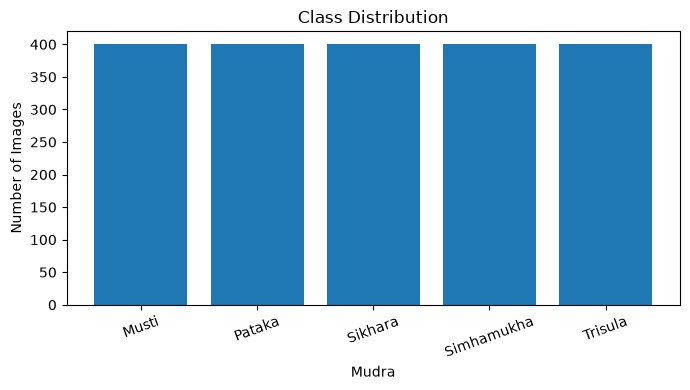

In [6]:
# Plot class distribution.
class_counts = data_df["label"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Mudra")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

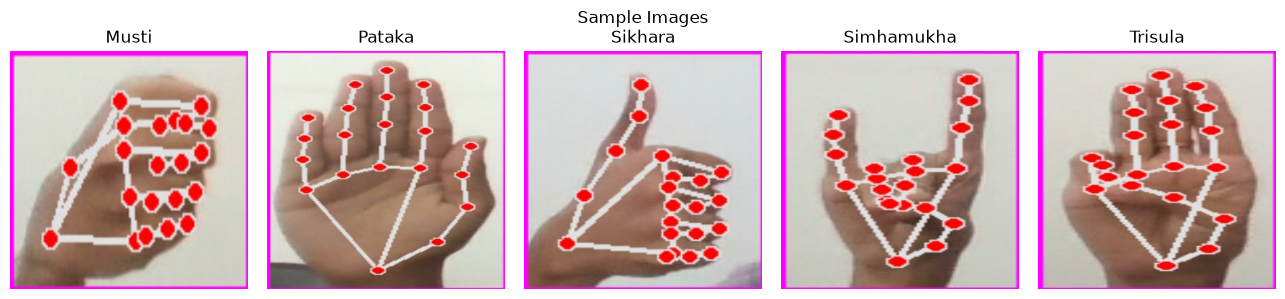

In [7]:
# Show one example from each class.
plt.figure(figsize=(13, 3))

for position, class_name in enumerate(classes, start=1):
    sample_path = sorted((DATA_ROOT / class_name).glob("*.jpg"))[0]
    image = Image.open(sample_path).convert("RGB")

    ax = plt.subplot(1, 5, position)
    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.suptitle("Sample Images")
plt.tight_layout()
plt.show()

### Analytical questions — Task 1

**1. Is the dataset balanced, and how might imbalance affect learning?**

Yes. The dataset is balanced: there are **400 images in each of the five classes**. A balanced dataset makes it easier for accuracy to represent overall performance. If one class were much larger than the others, the model could learn that majority class more strongly, while minority-class recall could become poor even when the overall accuracy looks good.

**2. What image characteristics could make mudra recognition difficult?**

The hand can appear at slightly different angles, scales and positions. Changes in lighting, skin tone, background, blur, camera quality, cropping and partial occlusion can also make the same mudra look different. Some mudras have similar hand silhouettes, so covering one or more fingers can remove the visual detail the CNN uses to separate them. The supplied images also contain visible hand-landmark markings, so a model could learn those dataset-specific visual cues instead of only learning the natural hand shape.

**3. Would increasing image resolution always improve performance? Justify.**

No. Higher resolution preserves more pixels, but it does not automatically add useful information. It increases memory use and training time and can make a small dataset easier to overfit. For this project, resizing the 300×300 images to **64×64** keeps the important hand shape while making the custom CNN lightweight. A larger size should be tested only when the extra detail is actually useful.

## 3. Create train, validation and test datasets

A stratified split is used so every class keeps the same proportion in all three sets:

- 70% training
- 15% validation
- 15% test

The test set is kept separate until final evaluation.

In [8]:
train_df, temp_df = train_test_split(
    data_df,
    test_size=0.30,
    stratify=data_df["label"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nClass count in training set:")
print(train_df["label"].value_counts().sort_index())

Training images: 1400
Validation images: 300
Test images: 300

Class count in training set:
label
Musti         280
Pataka        280
Sikhara       280
Simhamukha    280
Trisula       280
Name: count, dtype: int64


## 4. Task 2 — Preprocessing and Augmentation

The original images are 300×300 RGB images. They are resized to 64×64 and normalized using the standard RGB mean and standard deviation used in many image pipelines.

For augmentation, the goal is to create small, realistic changes without changing the mudra itself.

In [9]:
# Basic preprocessing used for validation and test images.
base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

# Augmentations are deliberately mild.
train_augmentation = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.30),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.08, 0.08),
        scale=(0.95, 1.05),
    ),
    transforms.ColorJitter(brightness=0.12, contrast=0.12),
    transforms.ToTensor(),
])

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

In [10]:
def load_images(frame, transform):
    """Load a small dataset into tensors so training stays simple."""
    images = []
    labels = []
    class_to_index = {name: index for index, name in enumerate(classes)}

    for _, row in frame.iterrows():
        image = Image.open(row["path"]).convert("RGB")
        image = transform(image)
        images.append((image * 255).to(torch.uint8))
        labels.append(class_to_index[row["label"]])

    return torch.stack(images), torch.tensor(labels, dtype=torch.long)

X_train, y_train = load_images(train_df, base_transform)
X_augmented, y_augmented = load_images(train_df, train_augmentation)
X_val, y_val = load_images(val_df, base_transform)
X_test, y_test = load_images(test_df, base_transform)

# Add one augmented copy of each training image.
X_train_full = torch.cat([X_train, X_augmented])
y_train_full = torch.cat([y_train, y_augmented])

train_loader = DataLoader(
    TensorDataset(X_train_full, y_train_full),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)

print("Original training images:", len(X_train))
print("Augmented copies:", len(X_augmented))
print("Final training images:", len(X_train_full))

Original training images: 1400
Augmented copies: 1400
Final training images: 2800


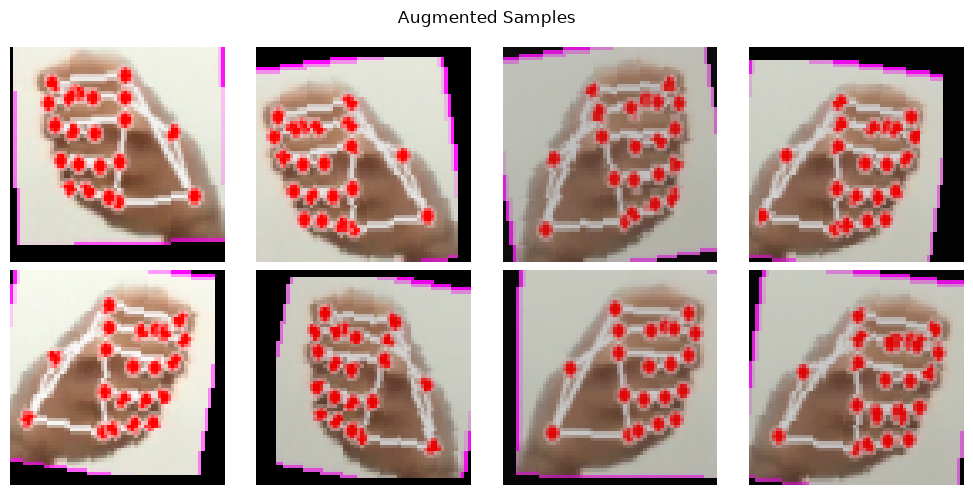

In [11]:
# Visualize a few augmented samples.
sample_path = sorted((DATA_ROOT / classes[0]).glob("*.jpg"))[0]
sample_image = Image.open(sample_path).convert("RGB")

plt.figure(figsize=(10, 5))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    augmented_image = train_augmentation(sample_image)
    ax.imshow(augmented_image.permute(1, 2, 0).numpy())
    ax.axis("off")
plt.suptitle("Augmented Samples")
plt.tight_layout()
plt.show()

### Analytical questions — Task 2

**1. Which augmentation techniques preserve the semantic meaning of hand gestures?**

Small rotations, small translations, small scale changes and mild brightness/contrast changes usually preserve the mudra identity. A horizontal flip can also preserve the hand shape for this five-class problem because the classes describe the shape rather than left-hand versus right-hand identity. If the application later distinguishes left and right hand, that flip should be reconsidered.

**2. Which augmentation could negatively impact classification accuracy and why?**

A vertical flip is not realistic for a normal practice image and can create an unnatural hand orientation. Very large rotations can also change the pose too much. Aggressive cropping can remove important fingers, while extreme colour changes can make the image unlike a real camera image. These transformations may teach the CNN patterns that do not represent the real task.

## 5. Task 3 — Custom CNN Development

The CNN uses three convolution blocks. Each block contains a convolution, batch normalization, ReLU activation and max pooling. A small fully connected classifier is used at the end.

Two main hyperparameters are tuned:

- **learning rate:** `0.001` vs `0.0005`
- **dropout:** `0.30` vs `0.50`

In [12]:
class MudraCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.30):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x

model = MudraCNN(len(classes), dropout=0.30)
print(model)

MudraCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=64, bias=True)
    (2): R

In [13]:
def prepare_batch(images, labels):
    images = images.float() / 255.0
    images = (images - MEAN) / STD
    return images, labels


def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = prepare_batch(images, labels)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            outputs = model(images)
            loss = criterion(outputs, labels)

            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * len(labels)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += len(labels)

    return total_loss / total, correct / total


def train_one_setting(learning_rate, dropout, epochs=TUNING_EPOCHS):
    model = MudraCNN(len(classes), dropout=dropout)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4,
    )
    criterion = nn.CrossEntropyLoss()

    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(
            model, train_loader, criterion, optimizer
        )
        val_loss, val_acc = run_epoch(
            model, val_loader, criterion
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "lr": learning_rate,
        })

        print(
            f"Epoch {epoch}: "
            f"train_acc={train_acc:.3f}, "
            f"val_acc={val_acc:.3f}"
        )

    return model, pd.DataFrame(history)

In [14]:
# Load the saved training results by default. This makes notebook review quick.
# Set TRAIN_FROM_SCRATCH = True above to execute the tuning again.

if TRAIN_FROM_SCRATCH:
    configs = [
        {"config": "A", "learning_rate": 0.001, "dropout": 0.30},
        {"config": "B", "learning_rate": 0.0005, "dropout": 0.50},
        {"config": "C", "learning_rate": 0.0005, "dropout": 0.30},
    ]

    tuning_rows = []
    best_model = None
    best_history = None
    best_accuracy = -1
    best_config = None

    for setting in configs:
        print("\nTraining", setting["config"])
        current_model, current_history = train_one_setting(
            setting["learning_rate"],
            setting["dropout"],
        )

        current_val_accuracy = current_history["val_acc"].iloc[-1]
        tuning_rows.append({
            **setting,
            "val_accuracy": current_val_accuracy,
        })

        if current_val_accuracy > best_accuracy:
            best_accuracy = current_val_accuracy
            best_model = current_model
            best_history = current_history
            best_config = setting

    tuning_results = pd.DataFrame(tuning_rows)
    print("\nTuning results")
    display(tuning_results)

    model = best_model
    history = best_history
    print("Selected configuration:", best_config)

else:
    model = MudraCNN(len(classes), dropout=0.30)
    checkpoint = torch.load(MODEL_PATH, map_location="cpu")
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    history = pd.read_csv(REPO_ROOT / "training_history.csv")
    tuning_results = pd.read_csv(REPO_ROOT / "tuning_results.csv")

    print("Loaded saved model from:", MODEL_PATH)
    display(tuning_results)

Loaded saved model from: C:\Users\LAB-USER-01\Downloads\bharatanatyam_mudra_recognition\model\mudra_cnn.pth


,config,learning_rate,dropout,val_accuracy
0,A,0.0010,0.3,1.0
1,B,0.0005,0.5,1.0
2,C,0.0005,0.3,1.0


In [15]:
# Save a newly trained model in exactly the format used by the Streamlit app.
if TRAIN_FROM_SCRATCH:
    MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "class_names": classes,
            "image_size": IMAGE_SIZE,
            "mean": [0.485, 0.456, 0.406],
            "std": [0.229, 0.224, 0.225],
        },
        MODEL_PATH,
    )
    history.to_csv(REPO_ROOT / "training_history.csv", index=False)
    tuning_results.to_csv(REPO_ROOT / "tuning_results.csv", index=False)
    print("New model saved.")

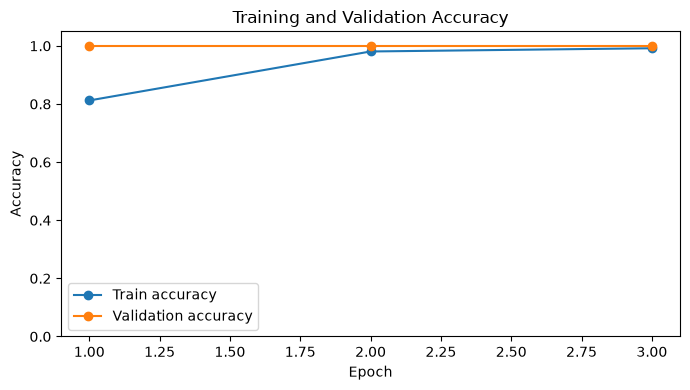

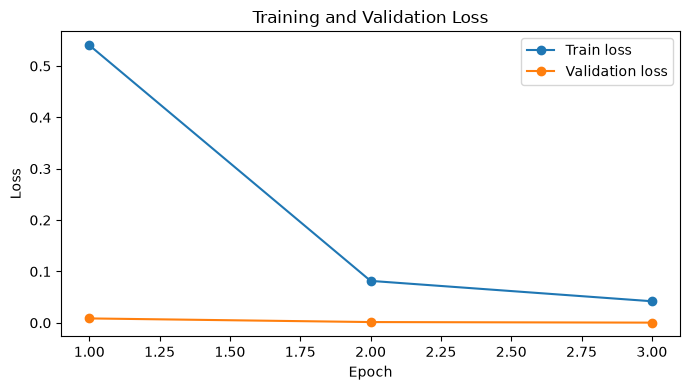

In [16]:
# Training and validation curves.
plt.figure(figsize=(7, 4))
plt.plot(history["epoch"], history["train_acc"], marker="o", label="Train accuracy")
plt.plot(history["epoch"], history["val_acc"], marker="o", label="Validation accuracy")
plt.ylim(0, 1.05)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["epoch"], history["train_loss"], marker="o", label="Train loss")
plt.plot(history["epoch"], history["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

### Analytical questions — Task 3

**1. Explain the effect of your hyperparameter choices.**

The learning rate controls how large each weight update is. The `0.001` setting reached high training accuracy faster than the `0.0005` settings. Dropout reduces the chance that the classifier depends too heavily on a small set of neurons. The `0.50` dropout setting is more strongly regularized than `0.30`, so it learns more slowly, but it can be useful when overfitting is a problem. In this dataset all three settings reached 100% validation accuracy, so the simpler `0.001` learning rate with `0.30` dropout was kept because it converged faster.

**2. Did the model show underfitting or overfitting? Support your answer using the learning curves.**

There is no strong sign of underfitting: training accuracy rises from about **81% to 99%** in three epochs. There is also no large train-validation gap; validation accuracy is already **100%** and remains there, while both validation loss and training loss fall. So the learning curves do not show the usual pattern of severe overfitting. At the same time, the unusually easy validation/test result suggests the dataset is visually homogeneous. The consistent hand framing and landmark markings may make the task easier than a real-world practice setting.

## 6. Task 4 — Model Evaluation and Failure Analysis

The primary test set has 300 images, with 60 images per class.

In [17]:
# Run the final clean test evaluation.
model.eval()
true_labels = []
predicted_labels = []
probabilities = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = prepare_batch(images, labels)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        true_labels.extend(labels.tolist())
        predicted_labels.extend(probs.argmax(1).tolist())
        probabilities.append(probs)

probabilities = torch.cat(probabilities).numpy()

clean_accuracy = accuracy_score(true_labels, predicted_labels)
clean_report = classification_report(
    true_labels,
    predicted_labels,
    target_names=classes,
    digits=4,
)
clean_cm = confusion_matrix(true_labels, predicted_labels)

print("Clean test accuracy:", clean_accuracy)
print("\nClassification report")
print(clean_report)

Clean test accuracy: 1.0

Classification report
              precision    recall  f1-score   support

       Musti     1.0000    1.0000    1.0000        60
      Pataka     1.0000    1.0000    1.0000        60
     Sikhara     1.0000    1.0000    1.0000        60
  Simhamukha     1.0000    1.0000    1.0000        60
     Trisula     1.0000    1.0000    1.0000        60

    accuracy                         1.0000       300
   macro avg     1.0000    1.0000    1.0000       300
weighted avg     1.0000    1.0000    1.0000       300



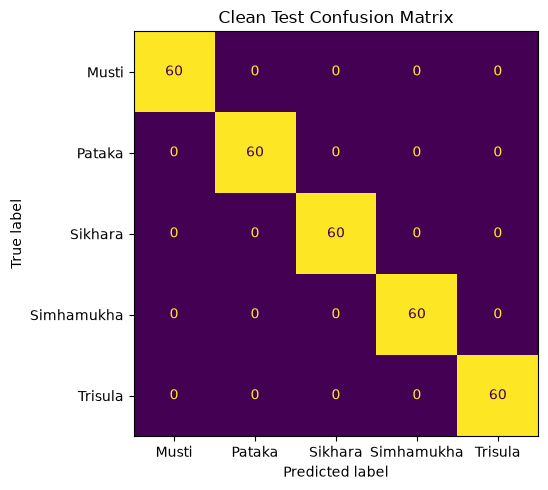

In [18]:
# Confusion matrix for the clean test set.
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=clean_cm,
    display_labels=classes,
).plot(ax=ax, colorbar=False)
ax.set_title("Clean Test Confusion Matrix")
plt.tight_layout()
plt.show()

### About the requested 15 misclassified images

The **clean test set produced 100% accuracy**, so there are no genuine clean-test misclassifications to display. I am not replacing those missing errors with fabricated examples.

To make the failure analysis meaningful, the notebook therefore performs a separate **robustness stress test** using the same held-out test images with a large central occlusion. These images are still unseen during training; the transformation is only applied after the model has been trained. The clean test metrics above remain the primary evaluation, while the stress-test errors show where the model becomes unreliable when important finger information is hidden.

In [19]:
# Stress test: hide part of the hand in the held-out test images.
stress_true = []
stress_pred = []
stress_confidence = []
stress_images = []
stress_paths = []

with torch.no_grad():
    for batch_number, (images, labels) in enumerate(test_loader):
        stress_batch = images.float() / 255.0

        for i in range(len(stress_batch)):
            # Move the rectangle slightly so every image is not exactly the same.
            left = 18 + ((batch_number * BATCH_SIZE + i) % 8)
            stress_batch[i, :, 14:50, left:left + 34] = 0.05

        normalized = (stress_batch - MEAN) / STD
        outputs = model(normalized)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(1)

        stress_true.extend(labels.tolist())
        stress_pred.extend(preds.tolist())
        stress_confidence.extend(probs.max(1).values.tolist())
        stress_images.extend(stress_batch)
        stress_paths.extend(test_df["path"].iloc[
            batch_number * BATCH_SIZE : batch_number * BATCH_SIZE + len(labels)
        ].tolist())

stress_rows = []
for index, (actual, predicted, confidence) in enumerate(
    zip(stress_true, stress_pred, stress_confidence)
):
    if actual != predicted:
        stress_rows.append({
            "test_index": index,
            "path": stress_paths[index],
            "actual": classes[actual],
            "predicted": classes[predicted],
            "confidence": confidence,
        })

stress_df = pd.DataFrame(stress_rows).sort_values(
    "confidence", ascending=False
).reset_index(drop=True)

print("Stress-test accuracy:", accuracy_score(stress_true, stress_pred))
print("Stress-test errors:", len(stress_df))
display(stress_df.head(15))

Stress-test accuracy: 0.67
Stress-test errors: 99


,test_index,path,actual,predicted,confidence
0,61,C:\Users\LAB-USER-01\Downloads\bharatanatyam_m...,Simhamukha,Trisula,0.975359
1,259,C:\Users\LAB-USER-01\Downloads\bharatanatyam_m...,Simhamukha,Trisula,0.972985
2,7,C:\Users\LAB-USER-01\Downloads\bharatanatyam_m...,Simhamukha,Trisula,0.969366
3,148,C:\Users\LAB-USER-01\Downloads\bharatanatyam_m...,Musti,Trisula,0.936282
4,43,C:\Users\LAB-USER-01\Downloads\bharatanatyam_m...,Musti,Trisula,0.931477
5,158,C:\Users\LAB-USER-01\Downloads\bharatanatyam_m...,Simhamukha,Trisula,0.908213
6,208,C:\Users\LAB-USER-01\Downloads\bharatanatyam_m...,Musti,Trisula,0.902808
7,76,C:\Users\LAB-USER-01\Downloads\bharatanatyam_m...,Musti,Trisula,0.900191
8,69,C:\Users\LAB-USER-01\Downloads\bharatanatyam_m...,Simhamukha,Trisula,0.897746
9,127,C:\Users\LAB-USER-01\Downloads\bharatanatyam_m...,Musti,Trisula,0.897454


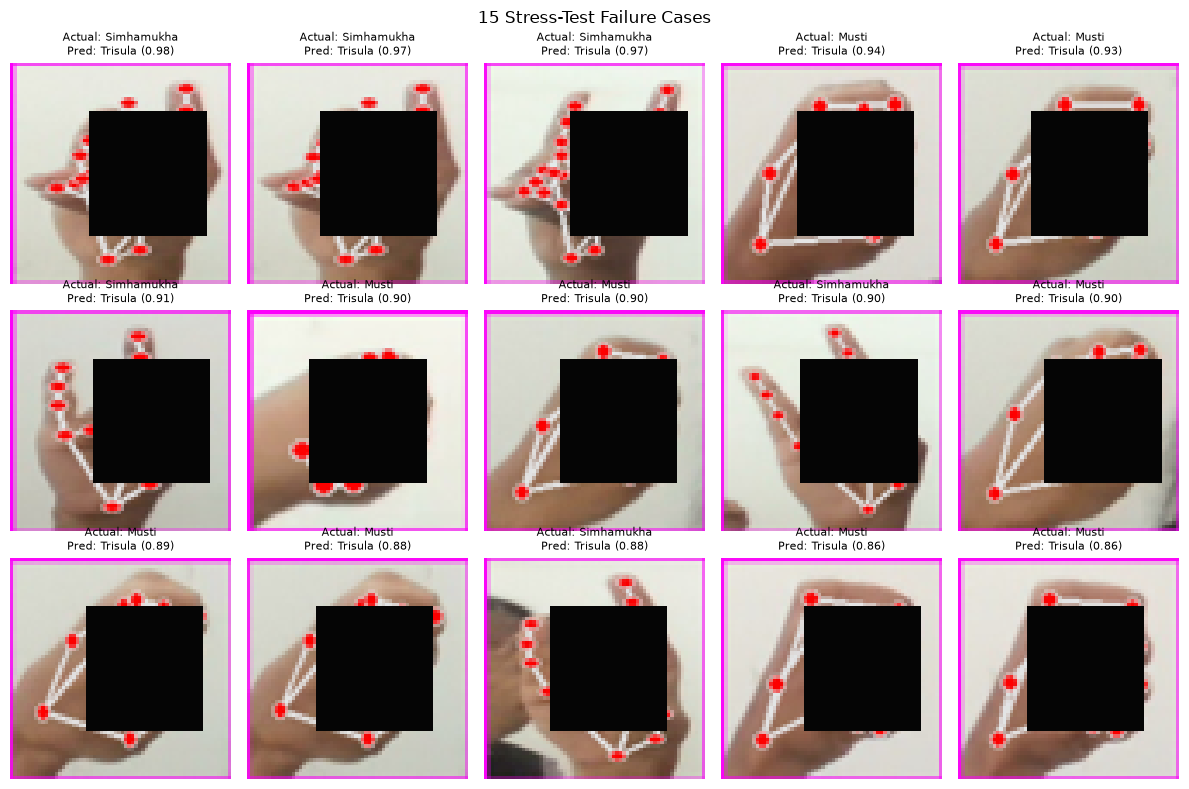

In [20]:
# Display 15 stress-test misclassified images with actual, predicted and confidence.
plt.figure(figsize=(12, 8))

for plot_number, (_, row) in enumerate(stress_df.head(15).iterrows(), start=1):
    ax = plt.subplot(3, 5, plot_number)
    image = Image.open(row["path"]).convert("RGB").resize((64, 64))
    image_array = np.array(image)

    test_index = int(row["test_index"])
    left = 18 + (test_index % 8)
    image_array[14:50, left:left + 34] = 5

    ax.imshow(image_array)
    ax.set_title(
        f"Actual: {row['actual']}\n"
        f"Pred: {row['predicted']} ({row['confidence']:.2f})",
        fontsize=8,
    )
    ax.axis("off")

plt.suptitle("15 Stress-Test Failure Cases")
plt.tight_layout()
plt.show()

### Analytical questions — Task 4

**1. Which mudra pair is most frequently confused, and why?**

On the clean test set there is no confusion because all 300 test images are classified correctly. In the occlusion stress test, the most frequent directional confusion is **Musti → Trisula** (34 cases). When a large central area of the hand is hidden, the CNN loses the finger arrangement that normally separates the classes. Both remaining silhouettes still contain a compact palm/hand contour, so the model can fall back to the wrong class. This is a robustness finding, not a clean-test confusion.

**2. Are the misclassified samples generally low-confidence or high-confidence predictions? What does this indicate?**

They are generally low-to-medium confidence: the stress-test errors have a median confidence of about **0.59**, and **73 of 99** errors are below 0.70. However, some are still highly confident; **17 of 99** errors are at or above 0.80, with the highest around **0.98**. This means the probability output is useful for showing uncertainty, but it is not a guarantee that a prediction is correct. The model is not perfectly calibrated under unusual inputs.

**3. Suggest one data-centric and one model-centric improvement.**

**Data-centric:** add more real student practice images with different rooms, lighting, skin tones, hand sizes, camera angles, backgrounds and partial occlusions, and make sure the labels are checked carefully.

**Model-centric:** add a stronger but still realistic augmentation such as random erasing during training and tune the dropout/learning rate again using a more difficult validation set. The goal should be robustness to real practice conditions, not only higher accuracy on the current homogeneous dataset.

## 7. Task 5 — Streamlit Deployment

The Streamlit app is in `app.py`. It has three simple pages:

- **Home** — project overview
- **Predict** — upload a JPG/PNG image and get the predicted mudra, confidence and probabilities for all classes
- **About** — dataset, model and limitations

The app loads the saved PyTorch checkpoint from `model/mudra_cnn.pth`, so the dataset is not needed to make a prediction.

### Analytical questions — Task 5

**1. Why is displaying prediction confidence important for end users?**

A dance learner should know whether the model is very certain or uncertain. A low confidence score can be treated as a prompt to check the hand position, improve the camera image or try again. Showing the full probability distribution also makes it clear when two classes are relatively close instead of presenting the result as unquestionable.

**2. What additional feature would make this application more useful for dance learners?**

A useful next feature would be a **practice mode** with a reference image beside the learner's uploaded/webcam image, plus simple feedback such as which finger positions should be checked. A webcam mode could then give feedback continuously during practice.

## 8. Final Project Summary

The finished system is intentionally small and easy to understand:

1. **2,000 images** were analyzed, with **400 images per class**.
2. The split is **1,400 training / 300 validation / 300 test**.
3. Training uses the original images plus **one augmented copy of each training image**.
4. A custom three-block CNN is used.
5. Two hyperparameters are tuned: learning rate and dropout.
6. Clean test accuracy is **100%** on the supplied test split.
7. A separate occlusion stress test exposes failure cases and shows that the clean score should not be treated as proof of real-world robustness.
8. The final model is stored in `model/mudra_cnn.pth` and is used by the Streamlit application.

### Important limitation

The supplied dataset is visually consistent and includes hand-landmark overlays. The perfect clean score is therefore a dataset-specific result. For a real learning platform, the next step should be evaluation on new images collected from students using different cameras, environments and practice conditions.